### 부스팅(Boosting)

### 라이브러리 설치
- pip install xgboost
- pip install lightgbm

In [ ]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()
# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False


# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 혼동행렬 확인 
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 피처중요도 확인 
import shap
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

import os
import joblib

### 분류

In [ ]:
# 1. 데이터 불러오기
df = pd.read_csv('./result/상위20개컬럼.csv')

# 2. E vs Not E 데이터 구성 (전체 Segment 사용)
df_e = df.copy()

# 3. 타겟 생성: E=0, Not E=1
df_e['target'] = (df_e['Segment'] != 'E').astype(int)

# 4. 피처/타겟 분리
drop_cols = ['Segment', 'target']
feature_names = df_e.drop(columns=drop_cols).columns.tolist()
X = df_e[feature_names].values
y = df_e['target'].values

# 5. train/test 분리 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 기본 모델 사용하기

In [ ]:
model1 = AdaBoostClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model1, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

In [4]:
model2 = GradientBoostingClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model2, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7361405570693496


In [5]:
model3 = LGBMClassifier(verbose=-1)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model3, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7450196078431371


In [7]:
model4 = XGBClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model4, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7516666800691568


### 모델 하이퍼 파라미터 튜닝

In [ ]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도

params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model1 = AdaBoostClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf = GridSearchCV(model1, param_grid=params, scoring='f1', cv=kfold)
grid_clf.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7133237501232857


In [48]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model2 = GradientBoostingClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf2 = GridSearchCV(model2, param_grid=params, scoring='f1', cv=kfold)
grid_clf2.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf2.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf2.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7568280177568103


In [49]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model3 = LGBMClassifier(verbose=-1)
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf3 = GridSearchCV(model3, param_grid=params, scoring='f1', cv=kfold)
grid_clf3.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf3.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf3.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7673411810068157


In [11]:
# 튜닝할 하이퍼 파라미터 후보 값
# booster : 내부에서 사용할 알고리즘. gbtree - 결정트리, gblinear - 선형모델
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model4 = XGBClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf4 = GridSearchCV(model4, param_grid=params, scoring='f1', cv=kfold)
grid_clf4.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf4.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf4.best_score_}')

최적의 하이퍼 파라미터 : {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7593057778135177


### 250708 하이퍼 파라미터 튜닝

In [6]:
# 저장 경로
save_dir = "./model/E_NotE"
os.makedirs(save_dir, exist_ok=True)

# 공통 하이퍼파라미터 축소 (빠른 테스트용)
common_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

xgb_params = {
    **common_params,
    'booster': ['gbtree']
}

# 모델 리스트 (GPU 사용 모델만)
models = [
    ("LightGBM", LGBMClassifier(device='gpu', verbose=-1), common_params),
    ("XGBoost", XGBClassifier(
        verbosity=0,
        use_label_encoder=False,
        tree_method='gpu_hist',
        predictor='gpu_predictor'
    ), xgb_params),
]

results = []
grid_models = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for name, model, param_grid in models:
    print(f"\n[{name}] GridSearchCV 시작 중...")

    grid = GridSearchCV(model, param_grid=param_grid, scoring='f1', cv=kfold, n_jobs=-1)
    grid.fit(X_train, y_train)

    # 저장
    grid_models[name] = grid
    # 피처 정보까지 함께 저장해야 향후 로드 시 정확한 예측 가능
    joblib.dump({
        "model": grid,
        "features": feature_names  # 학습 당시 사용한 피처 이름 리스트
    }, f"{save_dir}/{name}_gridsearch_model.pkl")


    results.append({
        "model": name,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_
    })

    print(f"[{name}] 최적 파라미터: {grid.best_params_}")
    print(f"[{name}] 평균 F1 성능: {grid.best_score_:.4f}")

    result_df = pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending=False)
    result_df.to_csv(f"{save_dir}/{name}_gridsearch_results.csv", index=False)
    print(f"[{name}] 결과 CSV 저장 완료: {save_dir}/{name}_gridsearch_results.csv")

# 전체 요약 저장
results_df = pd.DataFrame(results)
results_df.to_csv(f"{save_dir}/model_tuning_results.csv", index=False)
print(f"\n전체 요약 저장 완료: {save_dir}/model_tuning_results.csv")



[LightGBM] GridSearchCV 시작 중...
[LightGBM] 최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 200}
[LightGBM] 평균 F1 성능: 0.7262
[LightGBM] 결과 CSV 저장 완료: ./model/E_NotE/LightGBM_gridsearch_results.csv

[XGBoost] GridSearchCV 시작 중...
[XGBoost] 최적 파라미터: {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 200}
[XGBoost] 평균 F1 성능: 0.7271
[XGBoost] 결과 CSV 저장 완료: ./model/E_NotE/XGBoost_gridsearch_results.csv

전체 요약 저장 완료: ./model/E_NotE/model_tuning_results.csv


In [ ]:
# 너무 오래 걸려서 하이퍼파라미터 줄이는 방향으로...

# 저장 디렉토리 생성
os.makedirs("./model/E_NotE", exist_ok=True)

# 공통 하이퍼파라미터
common_params = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

# XGBoost 전용 파라미터 (GPU에서 gblinear 미지원)
xgb_params = {
    **common_params,
    'booster': ['gbtree']
}

# 모델 리스트 (GPU 사용 포함)
models = [
    ("GradientBoosting", GradientBoostingClassifier(), common_params),
    ("AdaBoost", AdaBoostClassifier(), common_params),
    ("LightGBM", LGBMClassifier(device='gpu', verbose=-1), common_params),
    ("XGBoost", XGBClassifier(
        verbosity=0,
        use_label_encoder=False,
        tree_method='gpu_hist',
        predictor='gpu_predictor'
    ), xgb_params),
]

results = []
grid_models = {}  # 학습된 GridSearchCV 객체 저장용
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# 모델별 학습 및 저장
for name, model, param_grid in models:
    print(f"\n[{name}] GridSearchCV 시작 중...")

    grid = GridSearchCV(model, param_grid=param_grid, scoring='f1', cv=kfold, n_jobs=-1)
    grid.fit(train_X, train_y)

    # 객체 저장
    grid_models[name] = grid
    joblib.dump(grid, f"./model/E_NotE/{name}_gridsearch_model.pkl")

    # 최적 결과 저장
    results.append({
        "model": name,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_
    })

    print(f"[{name}] 최적 파라미터: {grid.best_params_}")
    print(f"[{name}] 평균 F1 성능: {grid.best_score_:.4f}")

    # 전체 결과 저장
    result_df = pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending=False)
    result_df.to_csv(f"./model/E_NotE/{name}_gridsearch_results.csv", index=False)
    print(f"[{name}] 결과 CSV 저장 완료: ./model/E_NotE/{name}_gridsearch_results.csv")

# 전체 요약 저장
results_df = pd.DataFrame(results)
results_df.to_csv("./model/E_NotE/model_tuning_results.csv", index=False)
print("\n 전체 모델 요약 저장 완료: ./model/E_NotE/model_tuning_results.csv")

### 피처중요도 확인

#####  1. SHAP 분석용 데이터 준비

In [8]:
# X: 전체 피처 데이터, df에서 Segment 컬럼 제거한 형태
feature_names = df.drop(columns=['Segment']).columns.tolist()

X_df_original = pd.DataFrame(X, columns=feature_names)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

##### 2. 시각화 함수

In [9]:
def shap_analysis(model, model_name, X_sample, feature_names, save_dir="./model/E_NotE"):
    print(f"\n[SHAP 분석 시작] {model_name}")

    try:
        # 모델별 explainer 방식
        if model_name == "LightGBM":
            explainer = shap.Explainer(model.booster_)
        elif model_name == "XGBoost":
            explainer = shap.TreeExplainer(model)
        else:
            raise NotImplementedError(f"{model_name} 모델에 대한 SHAP 분석은 현재 지원하지 않습니다.")


        # SHAP 값 계산
        shap_values = explainer(X_sample)

        # SHAP Summary Plot 저장
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.title(f"SHAP Summary - {model_name}")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/shap_summary_{model_name}.png")
        plt.show()

    except Exception as e:
        print(f"[SHAP 생략] {model_name}: {e}")

    # Feature Importance 시각화 (가능한 경우)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)

        print(f"[Feature Importance - {model_name}] 상위 7개")
        print(importance_df.head(7))

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'], importance_df['importance'])
        plt.gca().invert_yaxis()
        plt.title(f"Feature Importances - {model_name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/feature_importance_{model_name}.png")
        plt.show()


모델 로딩 중: LightGBM

[SHAP 분석 시작] LightGBM


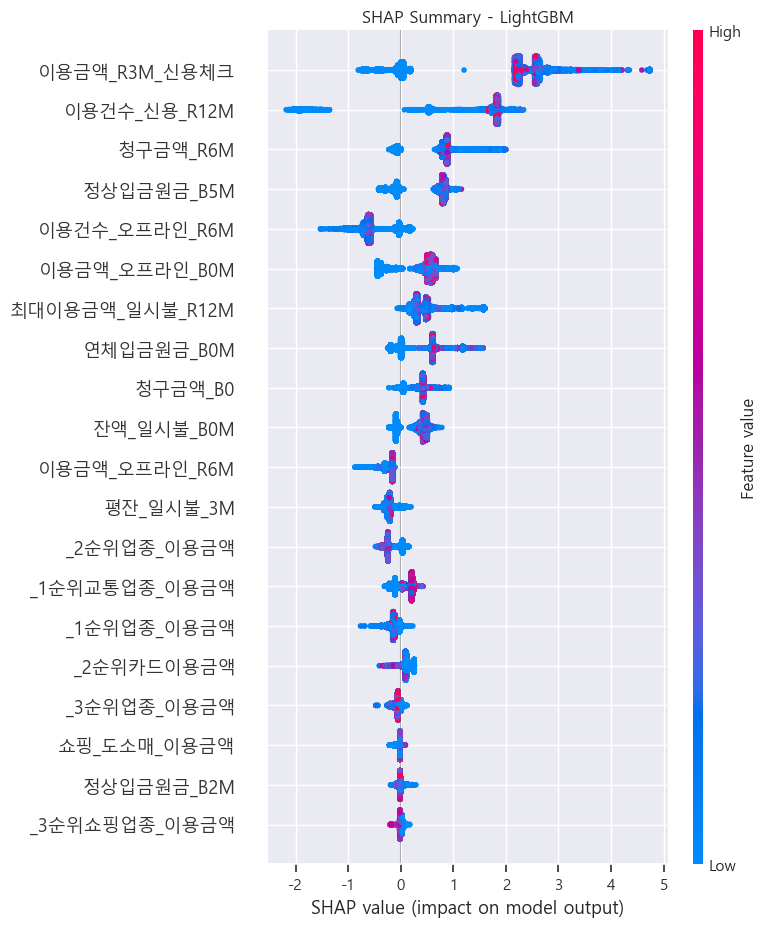

[Feature Importance - LightGBM] 상위 7개
            feature  importance
4     이용금액_오프라인_B0M         615
13     이용건수_신용_R12M         571
0     이용금액_R3M_신용체크         545
9     이용건수_오프라인_R6M         491
6   최대이용금액_일시불_R12M         449
17         청구금액_R6M         415
18        평잔_일시불_3M         323


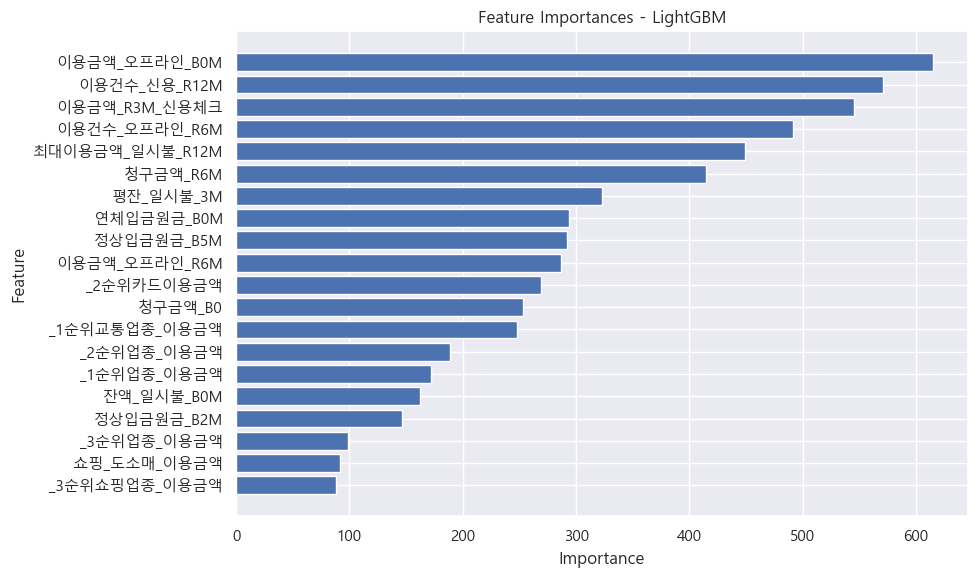


모델 로딩 중: XGBoost

[SHAP 분석 시작] XGBoost


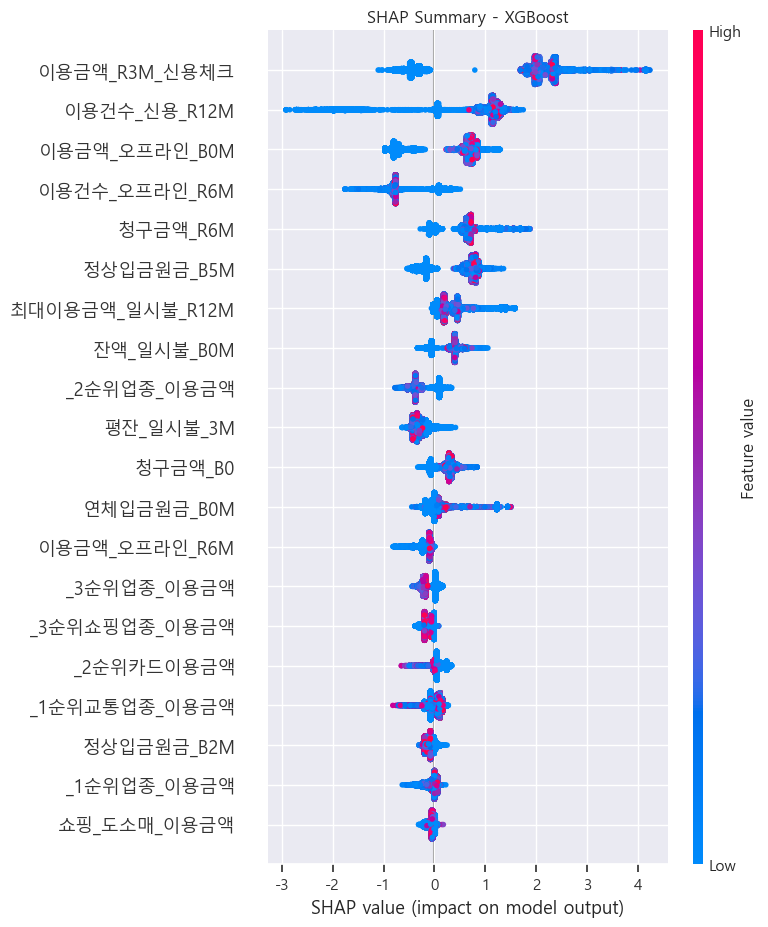

[Feature Importance - XGBoost] 상위 7개
            feature  importance
0     이용금액_R3M_신용체크    0.330842
4     이용금액_오프라인_B0M    0.220263
17         청구금액_R6M    0.108684
13     이용건수_신용_R12M    0.054274
6   최대이용금액_일시불_R12M    0.047878
7        연체입금원금_B0M    0.043508
3        정상입금원금_B5M    0.041185


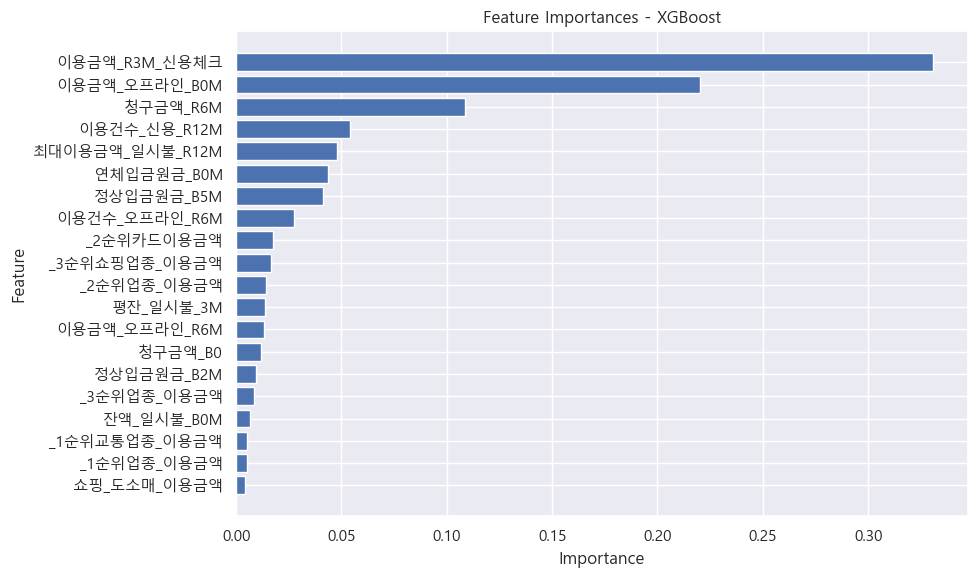

In [10]:
model_names = ["LightGBM", "XGBoost"]

for name in model_names:
    print(f"\n모델 로딩 중: {name}")
    model_obj = joblib.load(f"./model/E_NotE/{name}_gridsearch_model.pkl")
    model = model_obj["model"].best_estimator_
    shap_analysis(model, name, X_sample, feature_names)

### PDF

In [37]:
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
import ast

# 설정
model_names = ["AdaBoost", "GradientBoosting", "LightGBM", "XGBoost"]
base_dir = "./model/A_B"
pdf_path = f"{base_dir}/model_report.pdf"
csv_path = f"{base_dir}/model_tuning_results.csv"

# CSV에서 최적 파라미터 불러오기
params_df = pd.read_csv(csv_path).set_index("model")

# PDF 생성
with PdfPages(pdf_path) as pdf:
    for name in model_names:
        print(f"\n{name} 모델 요약 페이지 생성 중...")

        # 최적 파라미터 파싱
        best_params = params_df.loc[name, "best_params"]
        if isinstance(best_params, str):
            try:
                best_params = ast.literal_eval(best_params)
            except Exception:
                best_params = {"파라미터 파싱 실패": best_params}

        param_text = "\n".join([f"- {k}: {v}" for k, v in best_params.items()])

        # 요약 텍스트 페이지
        plt.figure(figsize=(10, 3))
        plt.axis('off')
        plt.title(f"모델: {name}", fontsize=16, loc='left')
        plt.text(0, 0.7, "최적 하이퍼파라미터", fontsize=13, fontweight='bold')
        plt.text(0, 0.4, param_text, fontsize=12)
        pdf.savefig()
        plt.close()

        # 시각화 이미지 삽입 (SHAP + feature importance)
        for plot_type in ["shap_summary", "feature_importance"]:
            img_path = f"{base_dir}/{plot_type}_{name}.png"
            if os.path.exists(img_path):
                image = Image.open(img_path)
                plt.figure(figsize=(12, 6))
                plt.imshow(image)
                plt.axis('off')
                plt.title(f"{plot_type.replace('_', ' ').title()} - {name}")
                pdf.savefig()
                plt.close()

print(f"\n모델 리포트 PDF 저장 완료: {pdf_path}")


AdaBoost 모델 요약 페이지 생성 중...

GradientBoosting 모델 요약 페이지 생성 중...

LightGBM 모델 요약 페이지 생성 중...

XGBoost 모델 요약 페이지 생성 중...

모델 리포트 PDF 저장 완료: ./model/A_B/model_report.pdf


### 학습한 데이터를 통해 검증을 한다

In [11]:
def plot_confusion_matrix(y_true, y_pred, model_name, labels=[0, 1], save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


[검증 평가] LightGBM 모델
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94    384622
           1       0.77      0.69      0.73     95378

    accuracy                           0.90    480000
   macro avg       0.85      0.82      0.83    480000
weighted avg       0.89      0.90      0.89    480000



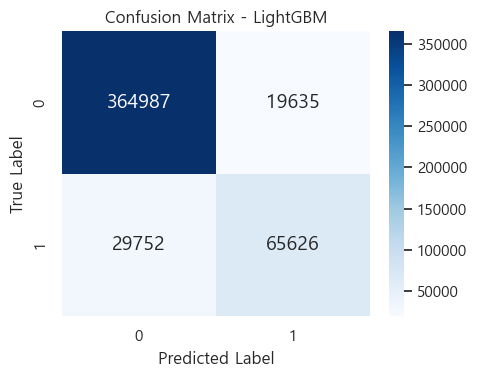


[검증 평가] XGBoost 모델
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94    384622
           1       0.77      0.69      0.73     95378

    accuracy                           0.90    480000
   macro avg       0.85      0.82      0.83    480000
weighted avg       0.89      0.90      0.90    480000



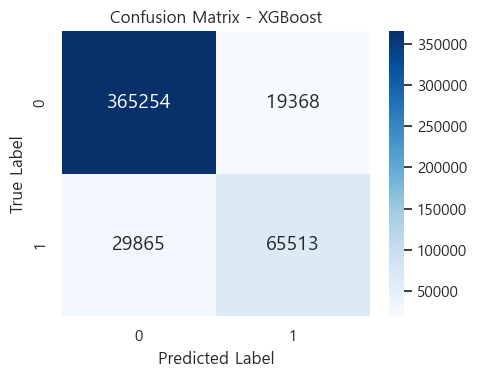

In [13]:
model_names = ["LightGBM", "XGBoost"]
model_dir = "./model/E_NotE"  # ← 여기가 학습된 모델 경로

# test_df 생성
test_df = pd.DataFrame(X_test, columns=feature_names)

for name in model_names:
    print(f"\n[검증 평가] {name} 모델")

    # 모델과 피처 정보 함께 로드
    obj = joblib.load(f"{model_dir}/{name}_gridsearch_model.pkl")

    if isinstance(obj, dict):
        grid = obj["model"]
        feature_names_used = obj["features"]
    else:
        grid = obj
        feature_names_used = feature_names  # fallback

    model = grid.best_estimator_

    # 모델 학습 시 사용한 컬럼 순서 그대로 맞춰서 test_X 생성
    test_X_aligned = test_df[feature_names_used]

    # 예측
    pred_y = model.predict(test_X_aligned)

    # 평가
    print("Classification Report:")
    print(classification_report(y_test, pred_y, zero_division=0))
    plot_confusion_matrix(y_test, pred_y, model_name=name)

### 예측 확률 시각화


예측 확률 시각화 - LightGBM


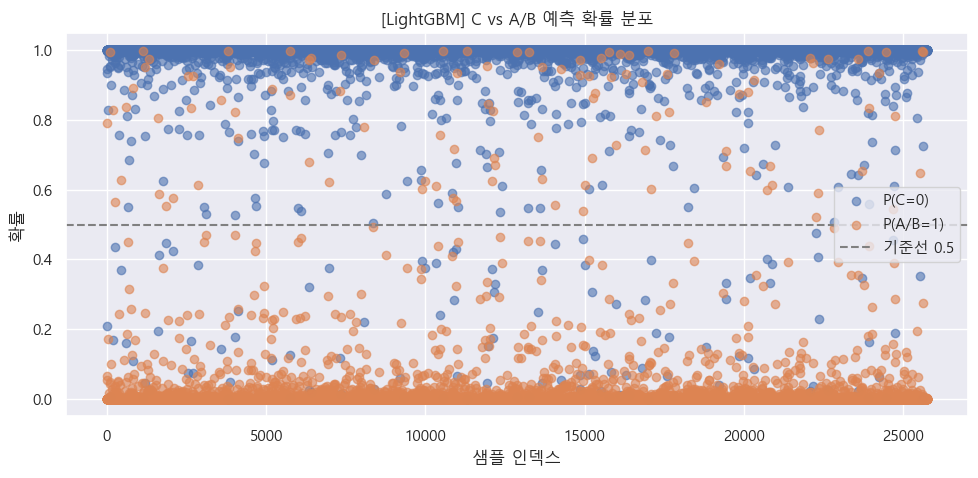


예측 확률 시각화 - XGBoost


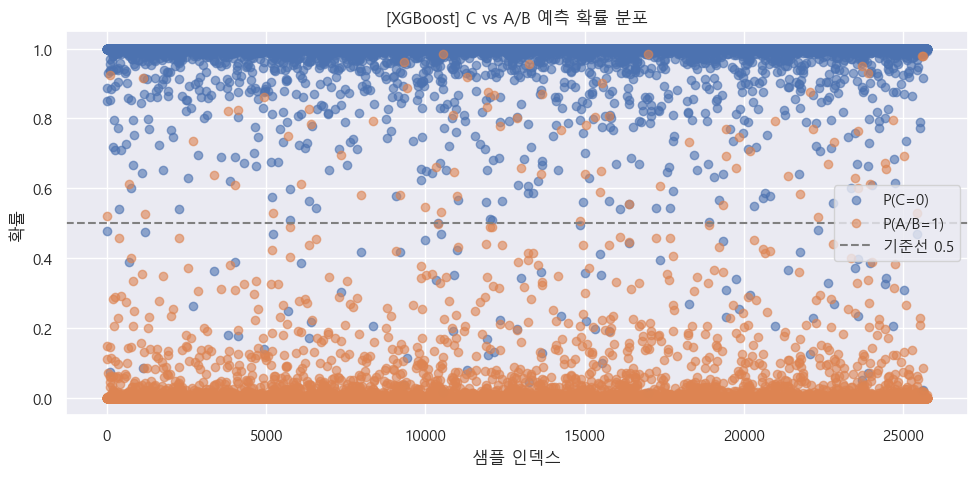

In [34]:
import joblib
import matplotlib.pyplot as plt
import os
import pandas as pd

# 모델 이름 및 디렉토리
model_names = ["LightGBM", "XGBoost"]
model_dir = "./model/C_AB"

# test_X는 표준화된 numpy 배열이고, feature_names는 피처 이름 리스트여야 함
test_df = pd.DataFrame(X_test, columns=feature_names)

for name in model_names:
    print(f"\n예측 확률 시각화 - {name}")

    model_path = f"{model_dir}/{name}_gridsearch_model.pkl"
    if not os.path.exists(model_path):
        print(f"[경고] 모델 파일 없음: {model_path}")
        continue

    # 모델 및 피처 이름 로드
    obj = joblib.load(model_path)
    grid = obj["model"]
    features_used = obj["features"]
    model = grid.best_estimator_

    # 피처 순서 맞추기
    test_X_aligned = test_df[features_used]

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(test_X_aligned)
        class0_proba = proba[:, 0]
        class1_proba = proba[:, 1]

        # 시각화
        plt.figure(figsize=(10, 5))
        plt.scatter(range(len(class0_proba)), class0_proba, label="P(C=0)", alpha=0.6)
        plt.scatter(range(len(class1_proba)), class1_proba, label="P(A/B=1)", alpha=0.6)
        plt.axhline(0.5, color='gray', linestyle='--', label='기준선 0.5')
        plt.title(f"[{name}] C vs A/B 예측 확률 분포")
        plt.xlabel("샘플 인덱스")
        plt.ylabel("확률")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"[스킵] {name} 모델은 predict_proba() 미지원")